# Traveller Sector Explorer

Generates a sector and lets you look round it: the maps, every system with
its secondary worlds, the candidates for Erith, and the places worth a
Referee's attention.

Run the cells in order. Everything after the generation cell reads the
sector that cell built, so you can re-run any of them freely.

**Requirements**: `pip install -r requirements.txt`. For the dropdown
pickers also `pip install ipywidgets` — without it the same views are
available as plain function calls, which every cell shows.

## 1. Settings

Change these and re-run from here. The seed makes a sector reproducible:
the same seed always gives the same sector.

In [1]:
SEED          = 1105          # any integer; change for a different sector
SECTOR_NAME   = "Foreven Reach"
WIDTH, HEIGHT = 32, 40        # a full sector; try 8, 10 for one subsector

# Canon: None, or a sector name published on travellermap.com such as
# "Foreven". Canonical star positions, borders and named worlds are then
# honoured and everything else generated around them.
CANON_SECTOR  = None
CANON_MODE    = "pin"         # "pin" | "seed" | "positions"

# Optional: a universe preset shapes density, technology and sophonts.
# One of None, "charted_space", "frontier", "pocket_empires",
# "fallen_empire", "deep_rift".
UNIVERSE_PRESET = None

In [2]:
import random
import worldmaker as wm
from IPython.display import SVG, Markdown, display

try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - the pickers fall back to function "
          "calls. pip install ipywidgets to enable them.")

print("worldmaker ready")

ipywidgets not installed - the pickers fall back to function calls. pip install ipywidgets to enable them.
worldmaker ready


## 2. Generate the sector

A full 32x40 sector is around 600 systems and takes a few seconds. Each
system is generated in full — stars, orbits, every world's physical and
social characteristics, secondary populations, and the nations of any
balkanised world.

In [3]:
random.seed(SEED)

canon = None
if CANON_SECTOR:
    canon = wm.fetch_canonical_sector(CANON_SECTOR)
    if CANON_SECTOR.lower().startswith("foreven"):
        canon = wm.merge_canon(canon, wm.scg_foreven(), name=CANON_SECTOR)
    print(canon.summary())
    print()

universe = (wm.create_universe(SECTOR_NAME, preset=UNIVERSE_PRESET)
            if UNIVERSE_PRESET else None)

sector = wm.generate_full_sector(
    SECTOR_NAME, width=WIDTH, height=HEIGHT,
    universe=universe, canon=canon, canon_mode=CANON_MODE)

inhabited = sum(1 for s in sector.systems.values()
                for b in s.all_bodies
                if getattr(b, 'is_secondary_world', False))

print(f"{len(sector.systems)} systems, {len(sector.polities)} polities, "
      f"{len(sector.native_sophonts)} sophont homeworlds")
print(f"{inhabited} inhabited secondary worlds beyond the mainworlds")
for p in sector.polities:
    print(f"  {p.allegiance_code:6s} {p.name:32s} "
          f"{len(p.controlled_systems):4d} worlds")

650 systems, 5 polities, 9 sophont homeworlds
761 inhabited secondary worlds beyond the mainworlds
  Ha     Halcyon Protectorate               86 worlds
  Vi     Vilis Directorate                  32 worlds
  Py     Pyrrhus Protectorate               34 worlds
  Xa     Xanthe Protectorate                17 worlds
  Si     Sindal Protectorate                46 worlds


## 3. The sector map

Classic Traveller idiom: starport letters, world discs, base glyphs,
travel-zone rings, dashed polity borders and each polity's own courier
network.

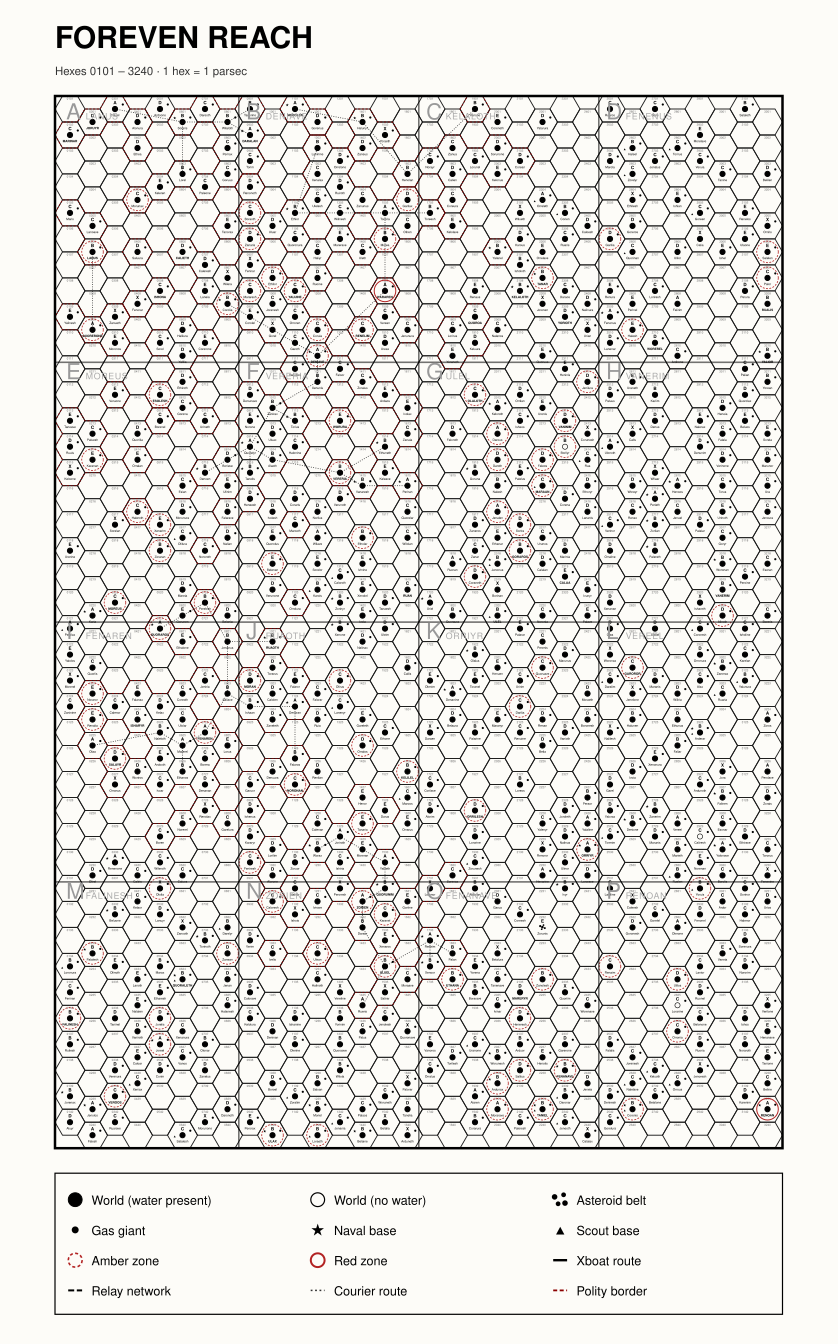

In [4]:
display(SVG(wm.generate_sector_svg(sector)))

## 4. Subsector maps

Pick a subsector A–P. Without ipywidgets, call `show_subsector("F")`.

**Subsector A: Lanus** — 35 systems

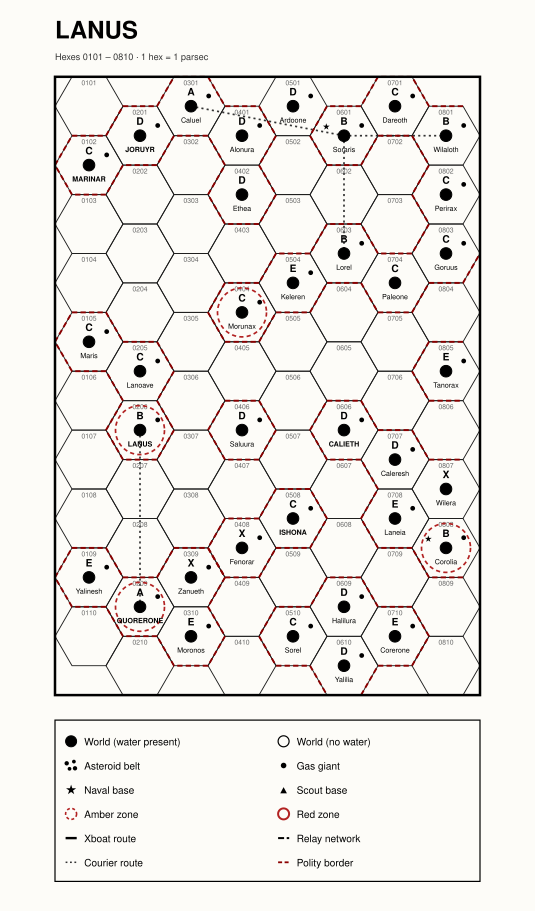

In [5]:
def show_subsector(letter="A"):
    """Renders one subsector at Supplement-page scale."""
    letter = letter.upper()
    index = ord(letter) - ord('A')
    if not 0 <= index < 16:
        print("Subsectors are lettered A to P.")
        return
    col = (index % 4) * 8 + 1
    row = (index // 4) * 10 + 1
    name = sector.subsector_names.get(letter, f"Subsector {letter}")
    count = sum(1 for h in sector.systems
                if col <= int(h[:2]) < col + 8 and row <= int(h[2:]) < row + 10)
    display(Markdown(f"**Subsector {letter}: {name}** — {count} systems"))
    display(SVG(wm.generate_subsector_svg(
        sector, name, origin_col=col, origin_row=row)))


if HAVE_WIDGETS and WIDTH == 32:
    widgets.interact(show_subsector,
                     letter=widgets.Dropdown(
                         options=[chr(ord('A') + i) for i in range(16)],
                         value='A', description='Subsector'))
else:
    show_subsector("A")

## 5. Every system at a glance

One row per system. `Inhabited` counts the mainworld plus any secondary
worlds with populations of their own — a figure the UWP never shows.

The result is an ordinary pandas DataFrame, so sort and filter it however
you like: `df.sort_values("Pop", ascending=False).head(20)`, or
`df[df["Zone"] == "R"]` for the interdicted systems.

In [6]:
df = wm.create_sector_dataframe(sector)
print(f"{len(df)} systems")
df.head(25)

650 systems


,Hex,Name,UWP,Bases,Zone,Allegiance,PBG,Trade codes,Stars,Worlds,Inhabited,Pop,Hab,Temp K,Nations
0,0102,Marinar,C888A86-7,,,Py,501,Hi,K8 V K3 V,9,2,50000000000,5,16.0,0
1,0105,Maris,C598120-4,M,,Py,523,Lo Lt,G0 V,10,1,50,1,237.1,0
2,0109,Yalinesh,EA88545-3,,,Py,403,Ag Lt Ni,K7 V,11,4,400000,5,166.0,0
3,0113,Taneave,E869422-3,,,Py,401,Lt Ni,M2 V,8,1,40000,7,271.3,0
4,0114,Ruuis,DCD7366-8,,,Py,702,Fl Lo,M5 V M9 V,7,1,7000,3,36.1,0
5,0115,Keloone,X868410-2,C,,Py,824,Lt Ni,K8 V,15,1,80000,12,280.1,0
6,0118,Urerine,E954665-6,,,Na,403,Ag Ni,G5 V,13,4,4000000,7,243.4,0
7,0121,Perolax,AAC9830-E,S,,Na,501,Fl Ht,K9 V M0 V M4 V M4 V M0 V,4,1,500000000,0,16.3,0
8,0122,Yalolos,EA88300-7,,,Na,520,Lo,G4 V M2 V M2 V M2 V,10,2,5000,3,149.1,0
9,0123,Morerel,X322230-8,C,,Na,721,Lo Po,K8 V,6,1,700,0,194.7,0


In [7]:
# A few useful views
display(Markdown("**Highest population**"))
display(df.sort_values("Pop", ascending=False).head(8))

display(Markdown("**Systems with inhabited secondary worlds**"))
display(df[df["Inhabited"] > 1].sort_values("Inhabited", ascending=False).head(8))

display(Markdown("**Interdicted and restricted systems**"))
display(df[df["Zone"] != ""][["Hex", "Name", "UWP", "Zone", "Allegiance"]].head(8))

**Highest population**

,Hex,Name,UWP,Bases,Zone,Allegiance,PBG,Trade codes,Stars,Worlds,Inhabited,Pop,Hab,Temp K,Nations
226,1210,Deniave,A767FGG-G,MN,A,Ha,624,Ga Hi Ht,G9 V K2 V,17,4,6000000000000000,4,326.6,0
19,0206,Lanus,BCE7BGK-F,M,A,Py,403,Fl Hi Ht,G4 V M3 V M5 V,10,5,400000000000,2,560.7,0
13,0136,Falinesh,B555AAA-E,,A,Na,902,Hi Ht,M3 V,11,6,90000000000,6,262.9,0
122,0725,Fenaren,A656ACG-F,M,A,Si,922,Ga Hi Ht,G3 V M4 V,8,4,90000000000,5,318.1,0
463,2338,Fenanave,BACAAAA-G,MN,A,Na,824,Fl Hi Ht In,M5 V,16,7,80000000000,0,216219.4,0
410,2118,Goraros,BC95AAD-9,M,A,Na,803,Hi In,G5 V M0 V,10,3,80000000000,4,46.2,0
185,1021,Ruaoth,BA66A89-B,MN,,Si,812,Hi,M1 V,12,6,80000000000,4,167.2,0
197,1101,Morolen,A988A79-G,MN,,Xa,813,Hi Ht,K7 V,11,4,80000000000,7,227.2,778


**Systems with inhabited secondary worlds**

,Hex,Name,UWP,Bases,Zone,Allegiance,PBG,Trade codes,Stars,Worlds,Inhabited,Pop,Hab,Temp K,Nations
293,1512,Ardaos,E977541-5,,,Ha,503,Ag Lt Ni,A6 V M0 V M0 V,15,7,500000,5,61.8,0
307,1539,Woruneth,C856878-B,M,,Na,426,Ga,M0 V,14,7,400000000,5,321.3,96
178,1012,Zanirax,B441499-A,,,Ha,803,Ni Po,K9 V,14,7,80000,5,280.2,0
463,2338,Fenanave,BACAAAA-G,MN,A,Na,824,Fl Hi Ht In,M5 V,16,7,80000000000,0,216219.4,0
13,0136,Falinesh,B555AAA-E,,A,Na,902,Hi Ht,M3 V,11,6,90000000000,6,262.9,0
11,0134,Loronura,B455852-A,S,,Na,904,,M3 V M8 V,15,6,900000000,2,233.5,0
231,1219,Karois,B767400-C,MS,,Na,422,Ga Ht Ni,M2 V M2 V,11,6,40000,7,961.6,0
350,1823,Denanine,AED7655-A,N,,Na,402,Fl Ni,G8 V,13,6,4000000,7,298.3,0


**Interdicted and restricted systems**

,Hex,Name,UWP,Zone,Allegiance
13,0136,Falinesh,B555AAA-E,A,Na
19,0206,Lanus,BCE7BGK-F,A,Py
20,0209,Quorerone,A887976-E,A,Py
22,0214,Karanan,E9675AB-3,A,Py
25,0223,Noraror,E8897AE-7,A,Si
26,0224,Renalia,EA986AA-4,A,Si
29,0233,Palalesh,BEB6642-9,A,Na
37,0320,Moreus,C56899C-9,A,Na


## 6. One system in full

Everything the generator knows about a system: its stars, its mainworld's
social profile, the nations of a balkanised world, and every secondary
world with its own population.

Pick a hex from the dropdown, or call `show_system("1515")`.

In [8]:
def show_system(hex_coord):
    """The full profile of one system, including its secondary worlds."""
    system = sector.systems.get(hex_coord)
    if system is None:
        print(f"No system at {hex_coord}.")
        return
    mw = system.mainworld
    out = [f"# {mw.name or system.name}  ({hex_coord})", ""]

    out.append(f"**UWP** `{mw.uwp}`  &nbsp; **Trade codes** "
               f"{', '.join(mw.trade_codes) or '-'}")
    zone = {'A': 'Amber', 'R': 'Red'}.get(system.travel_zone, 'Green')
    out.append(f"**Allegiance** {system.allegiance} &nbsp; **Zone** {zone} "
               f"&nbsp; **Bases** {', '.join(system.bases) or 'none'}")
    out.append(f"**System age** {system.age_gyr} Gyr &nbsp; "
               f"**Gas giants** {system.gas_giant_count} &nbsp; "
               f"**Belts** {system.planetoid_belt_count}")
    out.append("")

    out.append("## Stars")
    for star in system.stars:
        if star.is_composite:
            continue
        out.append(f"- **{star.designation}** {star.spectral_type} — "
                   f"mass {star.mass:.3f}, luminosity {star.luminosity:.4f}, "
                   f"habitable zone at Orbit# {star.hzco:.2f}")
    out.append("")

    out.append("## Mainworld")
    out.append(f"- Physical: size {mw.size_code}, "
               f"{int(mw.diameter_km or 0):,} km, gravity {mw.gravity}g, "
               f"{mw.mean_temperature}K ({mw.climate_zone})")
    out.append(f"- Atmosphere: {mw.atmosphere_name} "
               f"{mw.atmos_pressure_bar} bar, ppO2 {mw.partial_pressure_oxygen}")
    out.append(f"- Habitability {mw.habitability_rating}, "
               f"resources {mw.resource_rating}, life `{mw.native_lifeform_profile}`")
    if mw.total_population:
        out.append(f"- Population {mw.total_population:,} "
                   f"(profile {mw.population_profile}), "
                   f"{mw.urbanisation_pct}% urban")
        out.append(f"- Government: {mw.government_type} "
                   f"({mw.government_profile}); law {mw.law_profile}")
        out.append(f"- Technology {mw.technology_profile}; "
                   f"economics {mw.economic_extension}, WTN {mw.wtn}")
    if mw.major_cities:
        out.append("- Major cities: " + ", ".join(
            f"{c['name']} ({c['population']:,})" for c in mw.major_cities[:6]))
    for note in mw.notes[:6]:
        out.append(f"- *{note}*")
    out.append("")

    nations = getattr(mw, 'nations', None) or []
    if nations:
        out.append(f"## Nations ({getattr(mw, 'nation_count', len(nations))} "
                   f"sovereign states, {len(nations)} detailed)")
        for n in nations:
            seat = " — holds the starport" if n.holds_starport else ""
            culture = f", {n.culture_template}" if n.culture_template else ""
            out.append(f"- **{n.name}**{seat}: {n.government_type}, "
                       f"law {wm.Utils.eHex(n.law_level)}, "
                       f"TL {wm.Utils.eHex(n.tech_level)}, "
                       f"{n.population:,} people, {n.land_share}% of the "
                       f"land{culture}")
        out.append("")

    secondaries = [b for b in system.all_bodies
                   if getattr(b, 'is_secondary_world', False)]
    if secondaries:
        out.append("## Secondary worlds")
        for b in secondaries:
            kind = "colony" if b.affiliated else "independent"
            out.append(f"- **{b.designation}** `{b.uwp}` — {kind}, "
                       f"{b.total_population:,} people, "
                       f"{b.government_type}, TL {b.uwp.tech_level}")
        out.append("")
    else:
        out.append("*No inhabited secondary worlds.*")
        out.append("")

    others = [b for b in system.all_worlds
              if not b.is_mainworld and not getattr(b, 'is_secondary_world', False)]
    if others:
        out.append("## Other bodies")
        for b in others:
            moons = len([s for s in b.satellites if not s.is_ring])
            rings = " + rings" if any(s.is_ring for s in b.satellites) else ""
            moon_note = f", {moons} significant moons{rings}" if moons or rings else ""
            out.append(f"- {b.designation} — {b.body_type}, size {b.size_code}, "
                       f"Orbit# {b.orbit_num}{moon_note}")

    score, reasons = wm.notability(mw, system, sector, hex_coord)
    if reasons:
        out.append("")
        out.append("## Why this system is notable")
        for reason in reasons:
            out.append(f"- {reason}")

    display(Markdown("\n".join(out)))


hexes = sorted(sector.systems)
if HAVE_WIDGETS:
    widgets.interact(show_system,
                     hex_coord=widgets.Dropdown(options=hexes,
                                                value=hexes[0],
                                                description='System'))
else:
    show_system(hexes[0])

# Marinar  (0102)

**UWP** `C888A86-7`  &nbsp; **Trade codes** Hi
**Allegiance** Py &nbsp; **Zone** Green &nbsp; **Bases** none
**System age** 4 Gyr &nbsp; **Gas giants** 1 &nbsp; **Belts** 0

## Stars
- **A** K8 V — mass 0.580, luminosity 0.1238, habitable zone at Orbit# 0.88
- **D** K3 V — mass 0.740, luminosity 0.3155, habitable zone at Orbit# 0.00

## Mainworld
- Physical: size 8, 12,165 km, gravity 0.78g, 16.0K (Cryogenic (Glacial))
- Atmosphere: Dense 1.6782 bar, ppO2 0.4363
- Habitability 5, resources 10, life `7940`
- Population 50,000,000,000 (profile A-5-6-94%-5), 94% urban
- Government: Civil Service Bureaucracy (8-UJS); law 6-66784
- Technology 7-6-77777-7777-77-8; economics (A99+2), WTN 10
- Major cities: Ridge (19,740,000,000), Lake Vale (17,766,000,000), Landing (928,569,600), Lake Crossing (789,600,000), Haven (255,830,400)
- *Cultural Custom: Technological tools are treated as sacred relics.*
- *Cultural Taboo: Utilizing unregistered artificial intelligence tools.*
- *Faction 1: Religious Zealots (Size: Minor, Influence: High)*
- *Faction 2: Technological Technocrats (Size: Minor, Influence: Low)*
- *Faction 3: Corporate Hegemony (Size: Major, Influence: High)*

## Secondary worlds
- **A III** `C787161-6` — colony, 90 people, Captive Government / Colony, TL 6

## Other bodies
- A I — Terrestrial, size 8, Orbit# 2.24, 1 significant moons + rings
- A II — Gas Giant, size GLA, Orbit# 4.46, 11 significant moons + rings
- A IV — Terrestrial, size C, Orbit# 8.9
- A V — Terrestrial, size B, Orbit# 11.12, 1 significant moons
- A VI — Terrestrial, size 6, Orbit# 13.34
- A VII — Terrestrial, size 5, Orbit# 15.56, 2 significant moons + rings
- A IX — Terrestrial, size A, Orbit# 20.0, 1 significant moons

## Why this system is notable
- a population in the billions

## 7. Candidates for Erith

A very Earth-like world: Terra's own size, atmosphere and hydrographics,
balkanised, pre-industrial, in the habitable zone of an F, G or K star and
outside Zhodani space.

Scoring weights the physical characteristics hardest — a world of the right
size, air and water with the wrong Law Level is a far better answer than the
reverse — and Law and Tech are allowed a notch either way. Secondary worlds
are searched alongside mainworlds, so the answer may well be a moon.

In [9]:
candidates = wm.find_worlds(sector, wm.ERITH, limit=12)
print(wm.describe_matches(candidates, wm.ERITH))

Closest matches for Erith:
  A very Earth-like world: Terra's own size, atmosphere and hydrographics, a balkanised government and a pre-industrial technology, in the habitable zone of an F, G or K star and outside Zhodani space.
  Hex   Name           UWP         Score  Role             Star     Allegiance

  0637  Vanos          C877787-5   88.5%  mainworld        G7 V     Na
  2309  Yorioth        D867A97-9   87.4%  mainworld        K6 V     Na
  0617  Olilura        C879864-8   85.1%  mainworld        F8 V     Na
  1110  Garoth         C868457-6   85.1%  mainworld        G1 V     Ha
  0816  Falarave       D678767-3   82.8%  mainworld        K9 V     Ha
  0115  Keloone        X868410-2   81.0%  mainworld        K8 V     Py
  0701  Dareoth        C958655-9   80.5%  mainworld        G4 V     Py
  3211  Yorean         B886657-7   78.7%  mainworld        K3 V     Na
  1616  Quorelar       X565463-3   77.6%  secondary world  G5 V     Na
  0301  Caluel         A658744-B   77.0%  mainworld 

In [10]:
import pandas as pd

rows = []
for m in candidates:
    b = m.body
    rows.append({
        "Hex": m.hex, "Name": m.name, "UWP": m.uwp,
        "Score %": m.score,
        "Role": "mainworld" if m.is_mainworld else "secondary",
        "Star": m.star.spectral_type,
        "Temp K": b.mean_temperature,
        "Hab": b.habitability_rating,
        "Allegiance": m.system.allegiance,
        "Moon": getattr(b, 'parent_body', None) is not None,
    })
pd.DataFrame(rows)

,Hex,Name,UWP,Score %,Role,Star,Temp K,Hab,Allegiance,Moon
0,0637,Vanos,C877787-5,88.51,mainworld,G7 V,286.0,11,Na,False
1,2309,Yorioth,D867A97-9,87.36,mainworld,K6 V,270.6,9,Na,False
2,0617,Olilura,C879864-8,85.06,mainworld,F8 V,278.3,11,Na,False
3,1110,Garoth,C868457-6,85.06,mainworld,G1 V,280.8,11,Ha,False
4,0816,Falarave,D678767-3,82.76,mainworld,K9 V,280.9,10,Ha,True
5,0115,Keloone,X868410-2,81.03,mainworld,K8 V,280.1,12,Py,False
6,0701,Dareoth,C958655-9,80.46,mainworld,G4 V,300.4,12,Py,False
7,3211,Yorean,B886657-7,78.74,mainworld,K3 V,293.9,10,Na,False
8,1616,Quorelar,X565463-3,77.59,secondary,G5 V,293.1,7,Na,True
9,0301,Caluel,A658744-B,77.01,mainworld,G8 V,270.3,6,Py,False


### Making one of them Erith

An exact Erith is rare by chance, because generation ties Tech Level to
starport and population. `make_erith` takes the closest candidate, makes it
match exactly, rebuilds its nations, gives them a culture palette and
records the family holding the freehold.

On a balkanised world the freehold does not abolish the states: title and
ground disagree, which is the point.

In [11]:
erith = wm.make_erith(sector, culture_family="terrestrial")

if erith is None:
    print("No world in this sector passes the Erith filters. "
          "Try another seed.")
else:
    w = erith.body
    print(f"Erith is at {erith.hex}: {w.uwp}  ({erith.score}% match)")
    print(f"  star        {erith.star.spectral_type}, "
          f"habitable zone at Orbit# {erith.star.hzco:.2f}")
    print(f"  temperature {w.mean_temperature} K, "
          f"habitability {w.habitability_rating}")
    print(f"  a moon      {getattr(w, 'parent_body', None) is not None}")
    print(f"  proprietor  {w.proprietor['owner']}")
    print()
    print(wm.describe_nations(w))

Erith is at 0637: C867871-1  (100.0% match)
  star        G7 V, habitable zone at Orbit# 2.42
  temperature 286.0 K, habitability 11
  a moon      False
  proprietor  the Moncrieff family

Erith (C867871-1) - 188 sovereign states
  12 detailed below; the rest are flavour

  Bryne Republic: Impersonal Bureaucracy, Law D, TL 3, population 41,413,598
      land 15.2%; culture: renaissance
  Quarn Directorate: Self-Perpetuating Oligarchy, Law 5, TL 0, population 8,727,726
      land 34.3%; culture: neolithic
  Elmere Trust: Company/Corporation, Law 1, TL 1, population 60,798,397
      land 4.9%; culture: dark_age
  Amrit Republic: Civil Service Bureaucracy, Law 9, TL 0, population 104,686,064
      land 2.5%; culture: neolithic
  Nyle Compact: Representative Democracy, Law 0, TL 1, population 55,536,016
      land 4.9%; culture: classical
  Protectorate of Wold: Self-Perpetuating Oligarchy, Law 3, TL 2, population 21,780,797
      land 2.0%; culture: medieval
  Republic of Xanth: Impersona

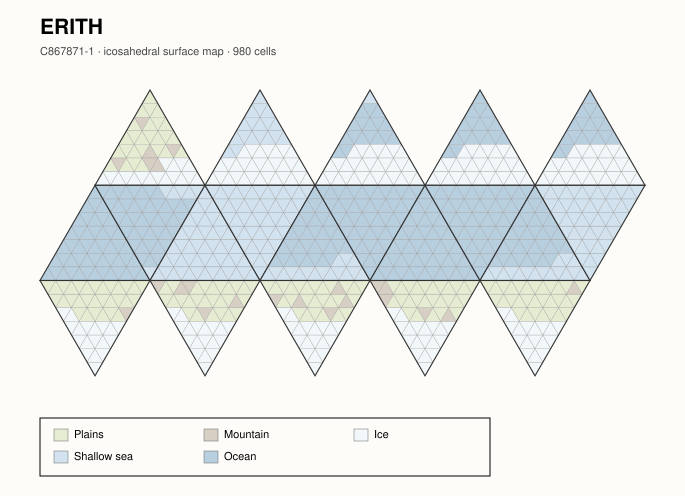

In [12]:
# Erith's surface, with its terrain
if erith is not None:
    display(SVG(wm.render_world_map_svg(erith.body)))

## 8. The worlds worth looking at

Several hundred systems and several thousand bodies, almost all of it
unremarkable rock. These cells surface the places that would change what
happens at the table, and say why each was flagged.

In [13]:
print(wm.describe_notable(
    wm.find_notable(sector, limit=12, kind='mainworld'),
    "Most notable mainworlds"))

Most notable mainworlds

  1514  Ethuneth       B875522-6   mainworld
        a native sophont species; the ruins of an extinct sophont species; a moon serving as its system's mainworld (+1 more)
  0512  Esolesh        CA679AC-5   mainworld
        the ruins of an extinct sophont species; hugely populous and pre-industrial; a rich and complex biosphere (+2 more)
  3206  Salelen        E9438BD-3   mainworld
        a native sophont species; constant volcanism and near-continuous earthquakes; populous and pre-industrial (+1 more)
  0616  Morunura       DA79561-8   mainworld
        a native sophont species; the ruins of an extinct sophont species; a ring system (+1 more)
  2701  Soris          CA8A79A-9   mainworld
        a native sophont species; the ruins of an extinct sophont species; a rich and complex biosphere
  2239  Taniel         B659AAF-C   mainworld
        the ruins of an extinct sophont species; a moon serving as its system's mainworld; a rich and complex biosphere (+2 more

In [14]:
print(wm.describe_notable(
    wm.find_notable(sector, limit=12, kind='secondary'),
    "Most notable secondary worlds"))

Most notable secondary worlds

  0404  Karuone        E47A165-A   secondary
        a native sophont species; the ruins of an extinct sophont species; a rich and complex biosphere (+3 more)
  1101  Alonim         CCEA367-E   secondary
        a native sophont species; the homeworld of the Gromoid; tidally locked, with a permanent day and night side (+2 more)
  1021  Ruaoth         D457468-A   secondary
        a native sophont species; the ruins of an extinct sophont species; a retrograde orbit (+2 more)
  0206  Peria          CA99353-F   secondary
        the homeworld of the Aslan; a radioactive atmosphere; technology at TLF (+3 more)
  0136  Renaen         E586265-C   secondary
        the ruins of an extinct sophont species; constant volcanism and near-continuous earthquakes; a rich and complex biosphere (+3 more)
  1014  Tananim        C676266-7   secondary
        a native sophont species; the ruins of an extinct sophont species; under a captive government (+1 more)
  1238  Orrir

### Exotic stellar systems

Dead stars are genuinely rare as primaries — about one system in a thousand
— so a sector may hold none at all. What surfaces here is usually giants,
subdwarfs and multiple-star systems.

The *World Builder's Handbook* is explicit about where the dwarfs actually
are: they "occupy 'empty' hexes" and are absent from commercial charts. The
next cell surveys that deep space.

In [15]:
print(wm.describe_notable(wm.find_exotic_systems(sector, limit=12),
                          "Most exotic stellar systems"))

Most exotic stellar systems

  1532  Karanel        CB8A8DB-9   system   
        a giant primary; a triple star system
  0833  Zanean         DCCA300-A   system   
        a giant primary
  3013  Falala         C788623-8   system   
        a giant primary
  0121  Perolax        AAC9830-E   system   
        5 stars
  0122  Yalolos        EA88300-7   system   
        4 stars
  0340  Ruarave        C778510-5   system   
        4 stars
  0426  Woriros        D844387-3   system   
        4 stars
  0501  Ardoone        DB69134-5   system   
        4 stars
  0526  Ardooth        E86358B-5   system   
        4 stars
  0532  Lanuyr         DA88111-3   system   
        5 stars
  0609  Halilura       D66A467-4   system   
        a subgiant primary
  0610  Yalilia        DBE9314-9   system   
        4 stars


In [16]:
# Survey the empty hexes for the objects that never reach a commercial
# chart: white and brown dwarfs, the odd neutron star, and rogue planets.
# On a full sector this takes a little while.
SURVEY_HEXES = 200      # raise for a fuller survey, or None for all of them

import itertools

empty = [f"{c:02d}{r:02d}"
         for c in range(1, sector.width + 1)
         for r in range(1, sector.height + 1)
         if f"{c:02d}{r:02d}" not in sector.systems]
if SURVEY_HEXES:
    empty = empty[:SURVEY_HEXES]

found = []
for hex_coord in empty:
    survey = wm.generate_empty_hex(name=f"Deep Space {hex_coord}")
    if survey.star_system is not None:
        survey.hex_coord = hex_coord
        sector.deep_space[hex_coord] = survey
        found.append((hex_coord, survey))

print(f"surveyed {len(empty)} empty hexes; "
      f"{len(found)} hold a star-like object\n")
for hex_coord, survey in found[:15]:
    star = survey.star_system.primary_star
    rogues = len(survey.rogue_worlds)
    print(f"  {hex_coord}  {star.spectral_type:14s} "
          f"mass {star.mass:6.3f}  "
          f"{len(survey.star_system.all_worlds):2d} worlds, "
          f"{rogues} rogue bodies")

surveyed 200 empty hexes; 109 hold a star-like object

  0101  BD             mass  0.074  11 worlds, 8 rogue bodies
  0104  BD             mass  0.038  10 worlds, 12 rogue bodies
  0107  BD             mass  0.025  11 worlds, 12 rogue bodies
  0108  BD             mass  0.036  12 worlds, 10 rogue bodies
  0112  D              mass  0.760   3 worlds, 9 rogue bodies
  0125  BD             mass  0.026   5 worlds, 12 rogue bodies
  0127  BD             mass  0.029   5 worlds, 13 rogue bodies
  0128  BD             mass  0.053   4 worlds, 10 rogue bodies
  0129  BD             mass  0.073  13 worlds, 8 rogue bodies
  0130  BD             mass  0.024   7 worlds, 8 rogue bodies
  0131  BD             mass  0.031  10 worlds, 8 rogue bodies
  0132  BD             mass  0.031  12 worlds, 11 rogue bodies
  0202  D              mass  0.310   2 worlds, 8 rogue bodies
  0203  BD             mass  0.043   8 worlds, 12 rogue bodies
  0208  BD             mass  0.025  10 worlds, 10 rogue bodies


## 9. Write it all out

The sector data in Traveller5 Second Survey format (which travellermap.com
reads), plus the maps.

In [17]:
from pathlib import Path

out = Path("output") / SECTOR_NAME.replace(" ", "_")
out.mkdir(parents=True, exist_ok=True)

(out / "sector.sec").write_text(wm.export_sector_sec_file(sector))
(out / "sector.tab").write_text(wm.export_sector_t5_tab(sector))
(out / "sector_map.svg").write_text(wm.generate_sector_svg(sector))
wm.create_sector_dataframe(sector).to_csv(out / "systems.csv", index=False)

for i in range(16):
    letter = chr(ord('A') + i)
    col, row = (i % 4) * 8 + 1, (i // 4) * 10 + 1
    if col > sector.width or row > sector.height:
        continue
    name = sector.subsector_names.get(letter, f"Subsector {letter}")
    (out / f"subsector_{letter}.svg").write_text(
        wm.generate_subsector_svg(sector, name, origin_col=col, origin_row=row))

if erith is not None:
    (out / "erith_map.svg").write_text(wm.render_world_map_svg(erith.body))
    (out / "erith.md").write_text(wm.describe_nations(erith.body))

print("written to", out.resolve())
for path in sorted(out.iterdir()):
    print("  ", path.name)

written to /home/user/worldmaker/output/Foreven_Reach
   erith.md
   erith_map.svg
   sector.sec
   sector.tab
   sector_map.svg
   subsector_A.svg
   subsector_B.svg
   subsector_C.svg
   subsector_D.svg
   subsector_E.svg
   subsector_F.svg
   subsector_G.svg
   subsector_H.svg
   subsector_I.svg
   subsector_J.svg
   subsector_K.svg
   subsector_L.svg
   subsector_M.svg
   subsector_N.svg
   subsector_O.svg
   subsector_P.svg
   systems.csv
